Cellule 1 — Imports

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

RANDOM_STATE = 42

Cellule 2 — Chargement du dataset

In [2]:
DATA_PATH = Path("../data/raw/bs140513_032310.csv")

df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape}")
df.head()

Shape: (594643, 10)


,step,customer,age,gender,zipcodeOri,merchant,zipMerchant,category,amount,fraud
0,0,'C1093826151','4','M','28007','M348934600','28007','es_transportation',4.55,0
1,0,'C352968107','2','M','28007','M348934600','28007','es_transportation',39.68,0
2,0,'C2054744914','4','F','28007','M1823072687','28007','es_transportation',26.89,0
3,0,'C1760612790','3','M','28007','M348934600','28007','es_transportation',17.25,0
4,0,'C757503768','5','M','28007','M348934600','28007','es_transportation',35.72,0


Examiner les variables

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 594643 entries, 0 to 594642
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   step         594643 non-null  int64  
 1   customer     594643 non-null  str    
 2   age          594643 non-null  str    
 3   gender       594643 non-null  str    
 4   zipcodeOri   594643 non-null  str    
 5   merchant     594643 non-null  str    
 6   zipMerchant  594643 non-null  str    
 7   category     594643 non-null  str    
 8   amount       594643 non-null  float64
 9   fraud        594643 non-null  int64  
dtypes: float64(1), int64(2), str(7)
memory usage: 45.4 MB


In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
step,594643.0,NaN,NaN,NaN,94.986827,51.053632,0.0,52.0,97.0,139.0,179.0
customer,594643,4112,'C1978250683',265,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,594643,8,'2',187310,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,594643,4,'F',324565,NaN,NaN,NaN,NaN,NaN,NaN,NaN
zipcodeOri,594643,1,'28007',594643,NaN,NaN,NaN,NaN,NaN,NaN,NaN
merchant,594643,50,'M1823072687',299693,NaN,NaN,NaN,NaN,NaN,NaN,NaN
zipMerchant,594643,1,'28007',594643,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,594643,15,'es_transportation',505119,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amount,594643.0,NaN,NaN,NaN,37.890135,111.402831,0.0,13.74,26.9,42.54,8329.96
fraud,594643.0,NaN,NaN,NaN,0.012108,0.109369,0.0,0.0,0.0,0.0,1.0


In [5]:
df.columns.tolist()

['step',
 'customer',
 'age',
 'gender',
 'zipcodeOri',
 'merchant',
 'zipMerchant',
 'category',
 'amount',
 'fraud']

Nettoyer les chaînes de caractères

In [6]:
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    df[col] = df[col].str.strip("'")

df.head()

C:\Users\bench\AppData\Local\Temp\ipykernel_15900\2971451087.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


,step,customer,age,gender,zipcodeOri,merchant,zipMerchant,category,amount,fraud
0,0,C1093826151,4,M,28007,M348934600,28007,es_transportation,4.55,0
1,0,C352968107,2,M,28007,M348934600,28007,es_transportation,39.68,0
2,0,C2054744914,4,F,28007,M1823072687,28007,es_transportation,26.89,0
3,0,C1760612790,3,M,28007,M348934600,28007,es_transportation,17.25,0
4,0,C757503768,5,M,28007,M348934600,28007,es_transportation,35.72,0


Vérification de la qualité des données

In [7]:
print("Missing values:")
print(df.isna().sum())

print("\nDuplicated rows:")
print(df.duplicated().sum())

Missing values:
step           0
customer       0
age            0
gender         0
zipcodeOri     0
merchant       0
zipMerchant    0
category       0
amount         0
fraud          0
dtype: int64

Duplicated rows:
0


In [8]:
print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")

Rows: 594,643
Columns: 10


Regarder le déséquilibre fraude / non-fraude

In [9]:
fraud_counts = df["fraud"].value_counts()

fraud_counts

fraud
0    587443
1      7200
Name: count, dtype: int64

In [10]:
fraud_rate = df["fraud"].mean()

print(f"Fraud rate: {fraud_rate:.4%}")

Fraud rate: 1.2108%


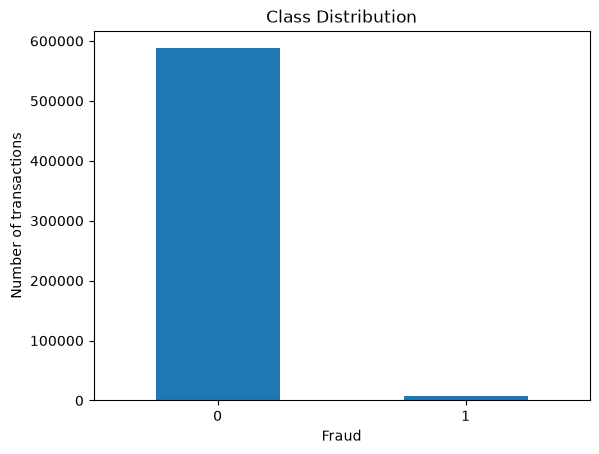

In [11]:
df["fraud"].value_counts().plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Fraud")
plt.ylabel("Number of transactions")
plt.xticks(rotation=0)
plt.show()

Distribution des montants

In [12]:
df["amount"].describe()

count    594643.000000
mean         37.890135
std         111.402831
min           0.000000
25%          13.740000
50%          26.900000
75%          42.540000
max        8329.960000
Name: amount, dtype: float64

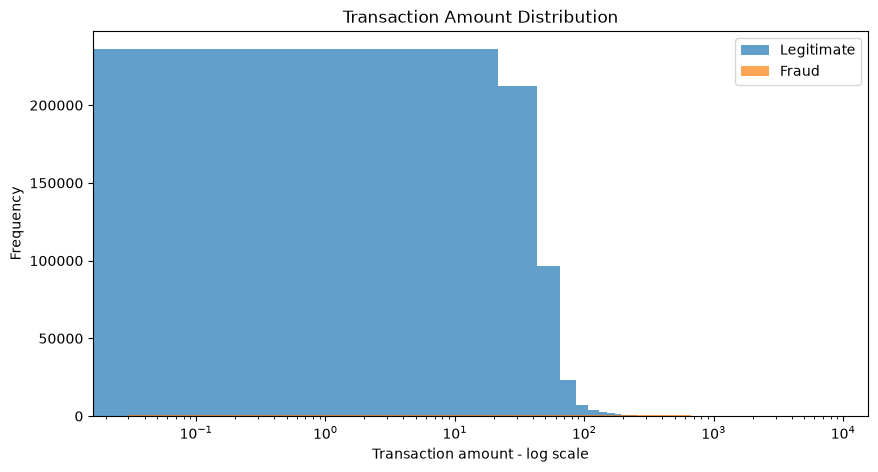

In [13]:
plt.figure(figsize=(10, 5))

plt.hist(
    df.loc[df["fraud"] == 0, "amount"],
    bins=100,
    alpha=0.7,
    label="Legitimate"
)

plt.hist(
    df.loc[df["fraud"] == 1, "amount"],
    bins=100,
    alpha=0.7,
    label="Fraud"
)

plt.xscale("log")
plt.xlabel("Transaction amount - log scale")
plt.ylabel("Frequency")
plt.title("Transaction Amount Distribution")
plt.legend()

plt.show()

In [14]:
category_analysis = (
    df.groupby("category")
    .agg(
        transactions=("fraud", "size"),
        frauds=("fraud", "sum"),
        fraud_rate=("fraud", "mean")
    )
    .sort_values("fraud_rate", ascending=False)
)

category_analysis

,transactions,frauds,fraud_rate
category,,,
es_leisure,499,474,0.949900
es_travel,728,578,0.793956
es_sportsandtoys,4002,1982,0.495252
es_hotelservices,1744,548,0.314220
es_otherservices,912,228,0.250000
es_home,1986,302,0.152064
es_health,16133,1696,0.105126
es_tech,2370,158,0.066667
es_wellnessandbeauty,15086,718,0.047594


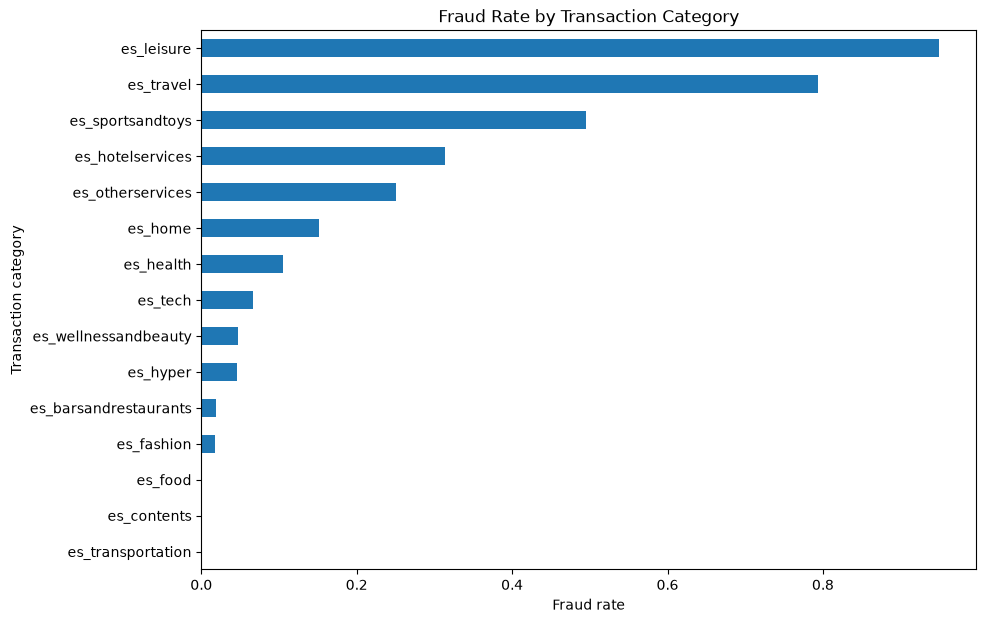

In [15]:
category_analysis["fraud_rate"].sort_values().plot(
    kind="barh",
    figsize=(10, 7)
)

plt.xlabel("Fraud rate")
plt.ylabel("Transaction category")
plt.title("Fraud Rate by Transaction Category")

plt.show()

Les cardinalités

In [16]:
df.nunique().sort_values()

zipMerchant        1
zipcodeOri         1
fraud              2
gender             4
age                8
category          15
merchant          50
step             180
customer        4112
amount         23767
dtype: int64

In [17]:
for col in ["age", "gender", "category"]:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- age ---
age
2    187310
3    147131
4    109025
5     62642
1     58131
6     26774
0      2452
U      1178
Name: count, dtype: int64

--- gender ---
gender
F    324565
M    268385
E      1178
U       515
Name: count, dtype: int64

--- category ---
category
es_transportation        505119
es_food                   26254
es_health                 16133
es_wellnessandbeauty      15086
es_fashion                 6454
es_barsandrestaurants      6373
es_hyper                   6098
es_sportsandtoys           4002
es_tech                    2370
es_home                    1986
es_hotelservices           1744
es_otherservices            912
es_contents                 885
es_travel                   728
es_leisure                  499
Name: count, dtype: int64


Les commerçants

In [18]:
merchant_analysis = (
    df.groupby("merchant")
    .agg(
        transactions=("fraud", "size"),
        frauds=("fraud", "sum"),
        fraud_rate=("fraud", "mean")
    )
    .sort_values("fraud_rate", ascending=False)
)

merchant_analysis.head(15)

,transactions,frauds,fraud_rate
merchant,,,
M1294758098,191,184,0.963351
M3697346,308,290,0.941558
M1873032707,250,216,0.864000
M732195782,608,518,0.851974
M980657600,1769,1472,0.832109
M1353266412,78,64,0.820513
M857378720,122,92,0.754098
M2080407379,48,36,0.750000
M2011752106,244,166,0.680328


Les montants fraude vs normal

In [19]:
df.groupby("fraud")["amount"].describe()

,count,mean,std,min,25%,50%,75%,max
fraud,,,,,,,,
0,587443.0,31.847230,31.470876,0.00,13.59,26.610,41.8950,2144.86
1,7200.0,530.926551,835.587112,0.03,159.98,319.175,548.9775,8329.96
